Rows after filtering: 392047
                          count          mean           std  min       25%  \
ClosePrice             392047.0  1.280467e+06  5.262803e+06  0.0  618000.0   
LivingArea             392047.0  2.036929e+03  3.834367e+03  0.0    1373.0   
BedroomsTotal          392047.0  3.476412e+00  9.601090e-01  0.0       3.0   
BathroomsTotalInteger  392047.0  2.607004e+00  1.149270e+00  0.0       2.0   
LotSizeSquareFeet      392047.0  2.409743e+05  1.357120e+07  0.0    5663.0   

                            50%        75%           max  
ClosePrice             885000.0  1425000.0  9.895000e+08  
LivingArea               1800.0     2418.0  2.308680e+06  
BedroomsTotal               3.0        4.0  4.500000e+01  
BathroomsTotalInteger       2.0        3.0  1.530000e+02  
LotSizeSquareFeet        7246.0    10332.0  2.087221e+09  


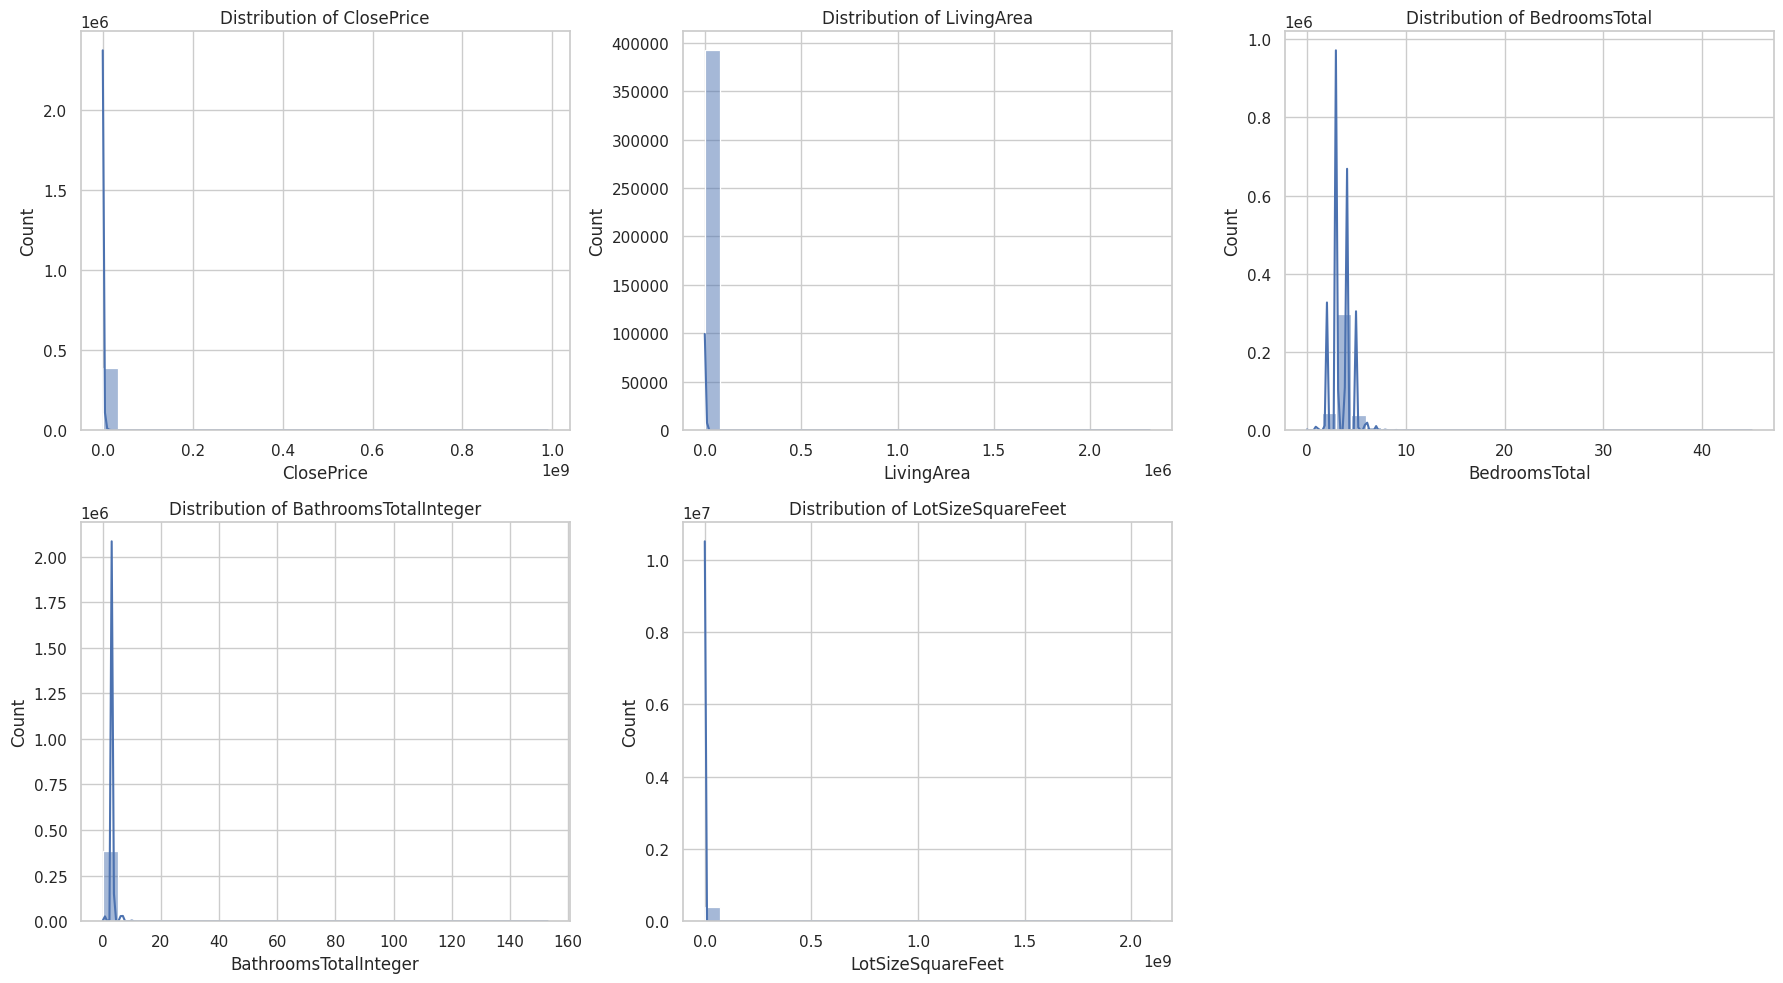

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_theme(style='whitegrid')

# Load the combined sold data
csv_path = Path('combined_sold.csv')
df = pd.read_csv(csv_path, low_memory=False)

# Restrict to the requested property segment
property_type = df['PropertyType'].astype(str).str.strip().str.lower()
property_subtype = df['PropertySubType'].astype(str).str.strip().str.lower()

mask = (property_type == 'residential') & (property_subtype == 'singlefamilyresidence')
subset = df.loc[mask].copy()

# Use the available column names for the requested variables
bedrooms_col = 'BedroomsTotal' if 'BedroomsTotal' in subset.columns else 'Bedrooms'
bathrooms_col = 'BathroomsTotalInteger' if 'BathroomsTotalInteger' in subset.columns else 'Bathrooms'
lot_col = 'LotSizeSquareFeet' if 'LotSizeSquareFeet' in subset.columns else 'LotSize'

numeric_cols = ['ClosePrice', 'LivingArea', bedrooms_col, bathrooms_col, lot_col]
for col in numeric_cols:
    subset[col] = pd.to_numeric(subset[col], errors='coerce')

subset = subset.dropna(subset=numeric_cols)

print(f'Rows after filtering: {len(subset)}')
print(subset[numeric_cols].describe().T)

# Visualize the distributions
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(subset[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Remove any unused subplot if needed
if len(numeric_cols) < len(axes):
    for ax in axes[len(numeric_cols):]:
        fig.delaxes(ax)

plt.tight_layout()
plt.show()


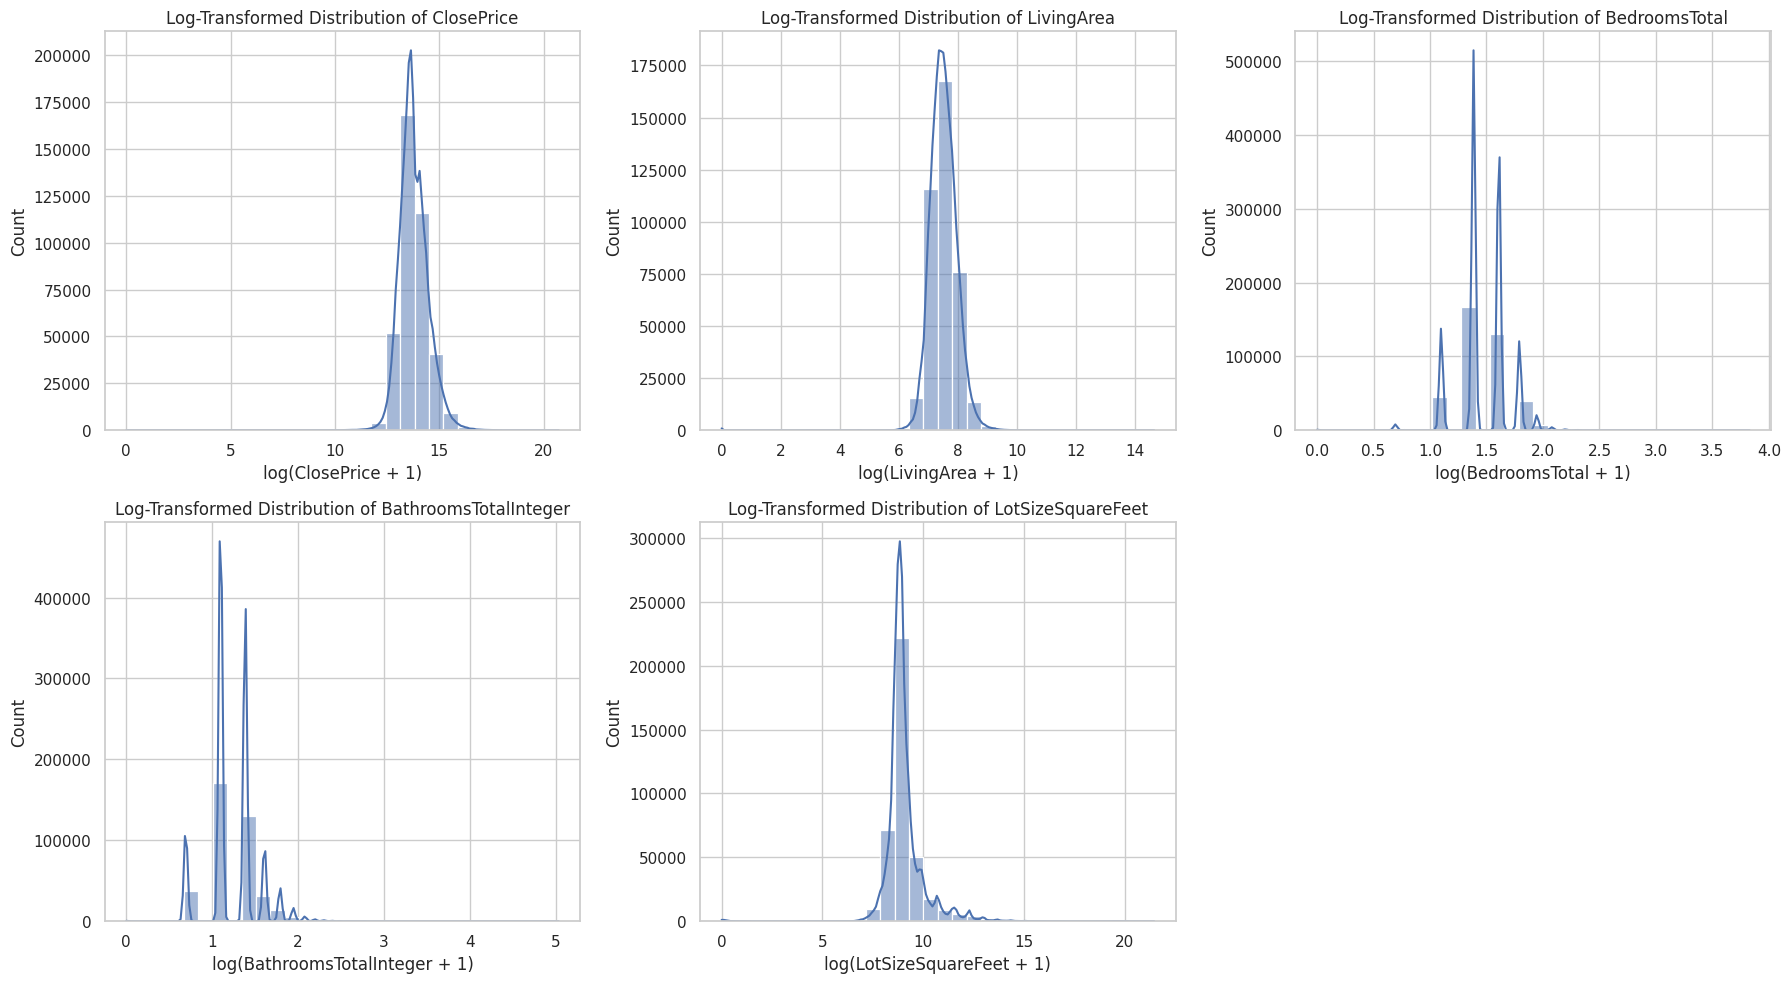


Log-transformed statistics:
                              count       mean       std  min        25%  \
ClosePrice_log             392047.0  13.772232  0.675192  0.0  13.334245   
LivingArea_log             392047.0   7.516285  0.455144  0.0   7.225481   
BedroomsTotal_log          392047.0   1.475923  0.216370  0.0   1.386294   
BathroomsTotalInteger_log  392047.0   1.240668  0.285806  0.0   1.098612   
LotSizeSquareFeet_log      392047.0   9.066497  0.970902  0.0   8.641886   

                                 50%        75%        max  
ClosePrice_log             13.693344  14.169683  20.712710  
LivingArea_log              7.496097   7.791110  14.652187  
BedroomsTotal_log           1.386294   1.609438   3.828641  
BathroomsTotalInteger_log   1.098612   1.386294   5.036953  
LotSizeSquareFeet_log       8.888343   9.243098  21.459099  


In [3]:
import numpy as np

# Log-transformed distributions to assess normality
# Add small offset to avoid log(0)
offset = 1
subset_log = subset.copy()
for col in numeric_cols:
    subset_log[col + '_log'] = np.log(subset_log[col] + offset)

# Plot log-transformed distributions
fig_log, axes_log = plt.subplots(2, 3, figsize=(18, 10))
axes_log = axes_log.flatten()

for ax, col in zip(axes_log, numeric_cols):
    sns.histplot(subset_log[col + '_log'], bins=30, kde=True, ax=ax)
    ax.set_title(f'Log-Transformed Distribution of {col}')
    ax.set_xlabel(f'log({col} + {offset})')
    ax.set_ylabel('Count')

# Remove any unused subplot if needed
if len(numeric_cols) < len(axes_log):
    for ax in axes_log[len(numeric_cols):]:
        fig_log.delaxes(ax)

plt.tight_layout()
plt.show()

print("\nLog-transformed statistics:")
log_cols = [col + '_log' for col in numeric_cols]
print(subset_log[log_cols].describe().T)
